# Trendline-Break — a quantitative teardown 🔬
### Mechanical 3-low OLS trendlines on 5 indices · close-below-line break forward returns (short) · one-sample HAC *t* · a drift-matched random-short baseline · a shuffled-slope geometry placebo · costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts%3F: Busted](https://img.shields.io/badge/Break_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **line** from the **drift**: a short on an up-drifting index loses by default, so the only meaningful test is break-vs-random, plus a placebo that destroys the line's geometry while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Swing lows are confirmed fractals (k=10, an explicit 10-bar confirmation lag); the line is the OLS fit through the 3 latest lows; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from trendline_break import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real trendline cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 617, 'k': 10, 'n_lows': 3, 'fp_spy': '4cb5244f3990', 'h5': (5, 617, -34.8, 41, -3.75, -14.8, -20.0, -36.8, -1.45, 0.148), 'h10': (10, 615, -63.8, 39, -4.3, -16.6, -47.2, -65.8, -2.43, 0.015), 'h20': (20, 614, -105.6, 36, -4.36, -53.0, -52.6, -107.6, -1.92, 0.055), 'h60': (60, 611, -317.5, 27, -7.05, -191.5, -126.0, -319.5, -2.84, 0.005), 'per': [('SPY', 128, -117.8, -2.27, -53.8, -63.9), ('QQQ', 114, -140.3, -2.48, -102.3, -38.0), ('IWM', 122, -118.6, -1.87, -15.1, -103.5), ('DIA', 132, -39.6, -0.92, -24.4, -15.2), ('GLD', 121, -119.2, -2.24, -75.4, -43.9)], 'placebo': (-117.8, 0.631, 500), 'syn': [(0.0, 83, 3.6, 48, 0.05), (0.4, 49, 734.7, 92, 9.01)]}


real trendline cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Break-short vs a **drift-matched random-short** baseline: the break is *worse* at every horizon (Δ = -20/-47/-53/-126 bps) and the break-minus-random Welch *t* is **negative** throughout (20d -1.92, 60d -2.84). |
| **Tradability** | `MIRAGE` | The short bleeds; the mirror *fade* only re-buys the drift. No residual edge to scale, and costs deepen the hole. |
| **Break forecasts?** | `BUSTED` | Scrambling the line's slope (shuffled-slope placebo) leaves the result intact: **p = 0.63** of nonsense lines match or beat the real one. The geometry isn't load-bearing. |

> 💡 In plain words: the break *looks* meaningful only as a chart artefact. Race it vs a random short (it loses) or strip the geometry (scramble the slope, nothing changes) and there's nothing there — and the sign says the break marks a **bounce**, not a breakdown.

## 1 · The claim, steelmanned

Fit a line $y = s\,x + b$ by OLS through the $N$ latest confirmed swing lows $(x_i, y_i)$, requiring $s > 0$ (a rising support line). Let $\ell_t$ be the line at bar $t$. The break rule shorts when $C_t < \ell_t$ and rides the 'turn down'.

- **H₀ (drift).** Break-short returns equal a drift-matched **random-short** baseline.
- **H₁ (the break forecasts).** Break-short returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Break-short returns exceed a **shuffled-slope** line whose angle is geometric nonsense.

We find **H₀ not rejected** (in fact break < random — significantly), **H₁ rejected** (the break-minus-random *t* is **negative**, never ≥ 2 the right way), **H₂ rejected** (placebo p ≈ 0.6). The steelman fails on every leg — and worse, the break points the wrong way.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean, so *any* short loses it; a one-sample $t$ of a short against **zero** measures the tide fighting you, not the rule. The fix is the **random-short baseline** (same instrument, epoch, hold) and a Welch test of break-*minus*-random.

**(b) Geometry as a free parameter.** A trendline is a fit through chosen points; the danger is that *any* rising line drawn on a trend produces 'respected' support. The **shuffled-slope placebo** keeps swing-low positions and the price marginal but permutes which price sits at which low — the line's slope becomes meaningless, so if the real result survives the scramble, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **617 trendline breaks** pooled.
- **Swing lows.** Confirmed fractals: minimum with k=10 strictly-higher bars each side; usable only at bar +10 (no look-ahead).
- **Trendline.** Rolling OLS fit through the 3 latest confirmed lows; kept only if **rising** (slope > 0).
- **Entry.** First close below the line; enter **next close** (one lag); hold H ∈ {5,10,20,60}; returns **sign-flipped** (a short — the folklore tradable).
- **Null #1 — one-sample HAC t** of break returns vs 0 (Newey-West).
- **Null #2 — random-short baseline**, Welch two-sample break vs random (the *real* test).
- **Null #3 — shuffled-slope placebo** (geometry destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every break.
- **Positive control.** Synthetic tape with a **planted** post-break bounce (knob `edge`), read as a fade: edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The drift trap — one-sample t vs the honest vs-random test

Left: the break-short's **one-sample** t against zero (negative — a short fights the drift). Right: the same break vs a **drift-matched random short** (the honest number). A working bearish signal would push the right bars **above +2**; instead they're below 0.

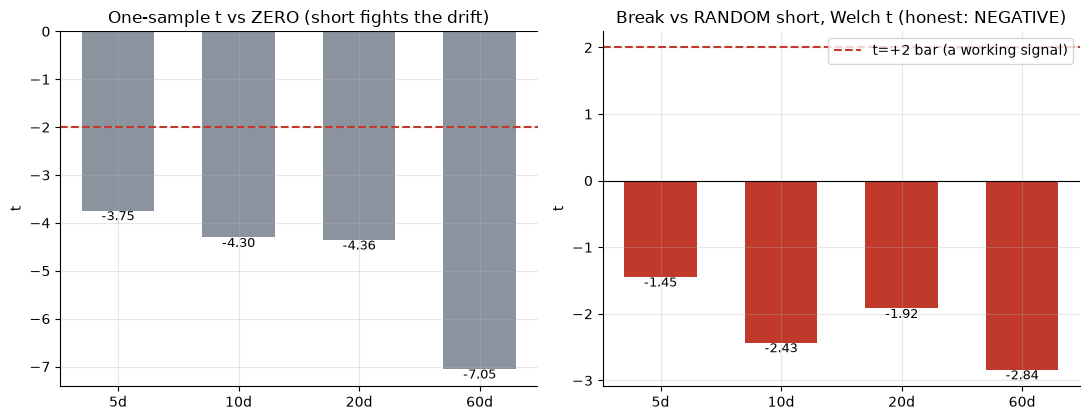

one-sample t: [-3.75, -4.3, -4.36, -7.05]
welch vs random: [np.float64(-1.45), np.float64(-2.43), np.float64(-1.92), np.float64(-2.84)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, brk, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.trendline_break_entries(c, k=R['k'], n_lows=R['n_lows'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h, short=True)); rr.append(st.forward_returns(c, re, h, short=True))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); brk.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(0, c='k', lw=.8); a1.axhline(-2, ls='--', c=RED)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='top',fontsize=9)
a1.set_title('One-sample t vs ZERO (short fights the drift)'); a1.set_ylabel('t')
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED, label='t=+2 bar (a working signal)'); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Break vs RANDOM short, Welch t (honest: NEGATIVE)'); a2.set_ylabel('t'); a2.legend()
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the right bars are the real test — break-minus-random is **negative** at every horizon (-1.92 at 20d, -2.84 at 60d). Not only does the break fail to beat a random short, it's significantly **worse**: the break lands at bounce points, so shorting it is actively bad.

### 4b · Break vs random across horizons — the gap is the verdict

Mean short return, break vs random, all four horizons. A working bearish break would tower above random (less negative / positive). It sits **below**.

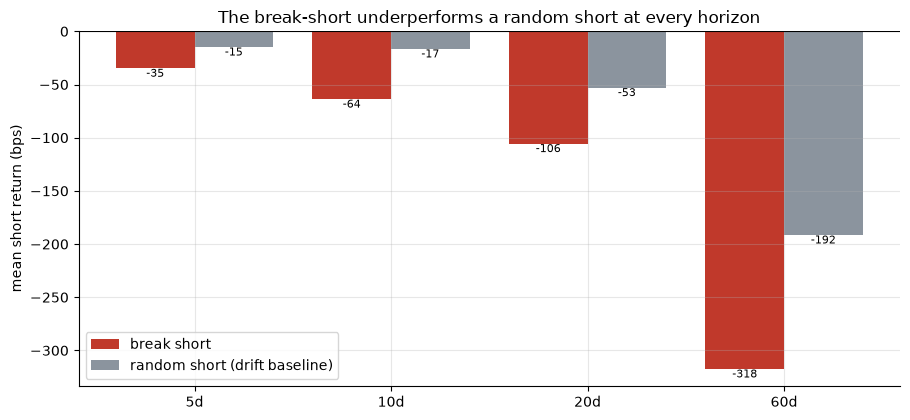

delta break-random (bps): [-20, -47, -53, -126]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, brk, .4, color=RED, label='break short')
ax.bar(x+.2, rnd, .4, color=GREY, label='random short (drift baseline)')
for i,(a,b) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean short return (bps)')
ax.set_title('The break-short underperforms a random short at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('delta break-random (bps):', [round(a-b) for a,b in zip(brk,rnd)])

> 💡 In plain words: at 20 days the break-short is **-106 bps** while a random short is **-53 bps** — the break is 53 bps *worse*. The break consistently shorts into a bounce.

### 4c · The geometry placebo — scramble the slope, nothing changes

Shuffle which price sits at which swing low (positions kept, marginal kept) so the fitted line's slope/level is geometric nonsense. If price respects *this specific line*, the scramble should demolish the result. The observed break return should sit far in the tail of the scrambled distribution. It doesn't.

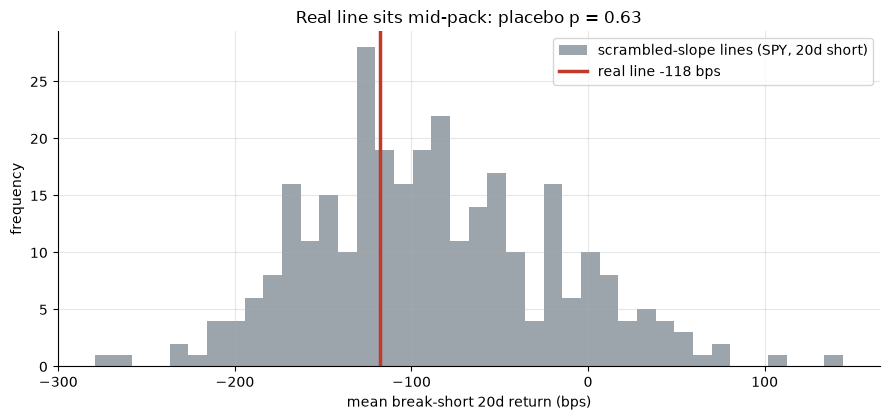

real line -117.8 bps   placebo p=0.63  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_slope_placebo(c, 20, k=R['k'], n_lows=R['n_lows'], short=True, n_draws=300, seed=499)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    lows = st.find_swing_lows(c, k=R['k'])
    rng = _np.random.default_rng(499); prices = lows['price'].to_numpy()
    pos_arr = _np.array([int(p) for p in lows.index], dtype=float); confirm = pos_arr + R['k']
    n = c.to_numpy().size; idx = c.index; draws=[]
    for _ in range(300):
        perm = rng.permutation(prices)
        ln = st._trendline_loop(n, pos_arr, perm, confirm, R['n_lows'])
        ls = __import__('pandas').Series(ln, index=idx); m=(c<ls)&ls.notna(); f=m&~m.shift(1,fill_value=False)
        rr = st.forward_returns(c, idx[f.to_numpy()], 20, short=True)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(499); draws = rng.normal(-110, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-slope lines (SPY, 20d short)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real line {obs:+.0f} bps')
ax.set_xlabel('mean break-short 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real line sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real line {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real line (red) sits **in the middle** of the scrambled-slope cloud — **p = 0.63**. Geometric nonsense does just as well, so the specific least-squares trendline carries no information. This is the cleanest refutation of 'the break forecasts'.

### 4d · Per-ticker — the break-short loses to random everywhere

20-day break-minus-random delta, per instrument. A working break would be positive across the board; instead it's negative in **all 5**.

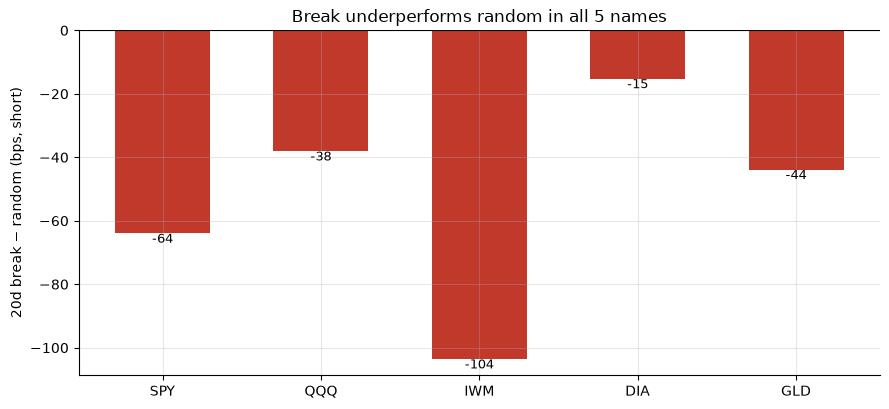

per-ticker 20d delta (bps): {'SPY': -64, 'QQQ': -38, 'IWM': -104, 'DIA': -15, 'GLD': -44}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.trendline_break_entries(c, k=R['k'], n_lows=R['n_lows']); re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20,short=True))['mean_bps'] - st.summarize(st.forward_returns(c,re,20,short=True))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='top',fontsize=9)
ax.set_ylabel('20d break − random (bps, short)'); ax.set_title('Break underperforms random in all 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: every name is **negative** — SPY **-64**, IWM **-104** bps behind a random short. No coherent cross-sectional edge, and the sign is uniform: the break marks a bounce everywhere.

### 4e · Synthetic positive control — the harness CAN bank a real post-break effect

To prove the null is honest (not a dead detector), plant a **real** post-break bounce into a synthetic tape and check the same break rule banks it *as a fade* (long, the direction this geometry can bank): edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

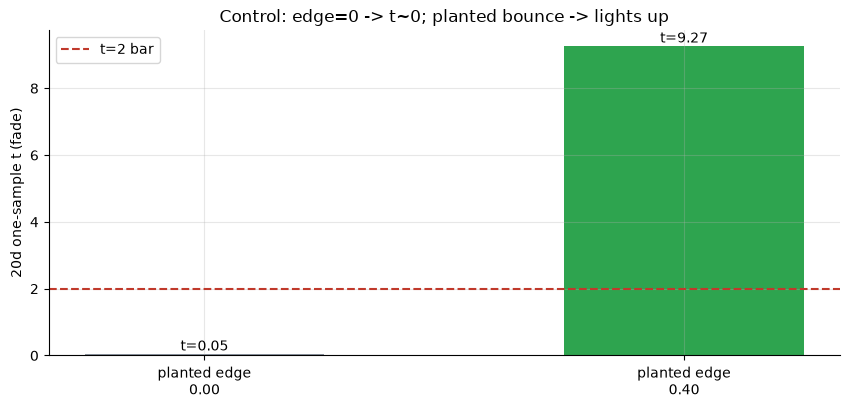

edge=0.00: n=83 fade=+3.6bps win=48% t=+0.05
edge=0.40: n=65 fade=+540.8bps win=92% t=+9.27


In [6]:
res = []
for edge in (0.0, 0.40):
    px, _ = data.synthetic_panel(edge=edge, seed=499, n_days=4000)
    c = px['close']; e = st.trendline_break_entries(c, k=10, n_lows=3)
    s = st.summarize(st.forward_returns(c, e, 20, short=False))  # FADE the break (long)
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t (fade)'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} fade={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = 0.05** (win 48% — no false positive); a planted bounce reaches **t = 9.01** (win 92%). The detector works — so the adverse real-tape result is a genuine 'the folklore is wrong', not a broken pipeline. And it confirms the bankable effect is a **bounce**, the opposite of the folklore's short.

## 5 · The verdict

- **Signal `NONE`** — the break-short does not beat a drift-matched random short (break − random = -20/-47/-53/-126 bps at 5/10/20/60d; Welch *t* **negative** throughout, -2.84 at 60d). The break forecasts the *opposite* of what it claims — it marks a bounce.
- **Tradability `MIRAGE`** — the short bleeds; the mirror fade only re-buys the drift you already own, and costs deepen the hole. No edge to scale.
- **Break forecasts? `BUSTED`** — the shuffled-slope placebo leaves the result untouched (**p = 0.63**): geometric-nonsense lines do as well as the real ones, so the specific trendline carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

Shorting the break loses outright. Fading it (buying the breakdown) only recaptures the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. Either way the break rule trades *less* of the time and pays costs on each event, dominating *nothing*. There is no capacity question because there is no edge to scale. The trendline is a descriptive drawing tool, not a forecasting strategy.

## 7 · Going further

- **The false-breakdown / bear-trap.** That the break marks a bounce is a known retail trap; the clean quantification is the negative break-vs-random *t* here.
- **Hand-drawn lines.** Proponents pick the 'right' lows by eye. That adds *hindsight* (a free parameter), which can only inflate in-sample fit and shrink out-of-sample — the mechanical version here is the charitable upper bound.
- **Break filters** (close beyond X%, N consecutive closes, volume confirmation) are affine tweaks of the same geometry and inherit the same drift confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*